In [ ]:

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c nn-26-scene-style-classification
!unzip -q nn-26-scene-style-classification.zip -d /content/data

Saving kaggle.json to kaggle.json
 98% 1.13G/1.15G [00:14<00:00, 185MB/s]
100% 1.15G/1.15G [00:14<00:00, 86.6MB/s]


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input, mixed_precision
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt
import os
import numpy as np
import glob
from collections import Counter
import pandas as pd
from sklearn.model_selection import train_test_split

policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

TRAIN_DIR = "/content/data/StyleClassificationIndoors/StyleClassificationIndoors/train"
TEST_DIR  = "/content/data/StyleClassificationIndoors/StyleClassificationIndoors/test"

IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32
NUM_CLASSES = 17
TARGET_SAMPLES_PER_CLASS = 2000
VAL_SPLIT_RATIO = 0.2
AUTOTUNE = tf.data.AUTOTUNE

STEPS_PER_EPOCH = 34000 // BATCH_SIZE

CLASS_NAMES = ['asian', 'boho', 'coastal', 'contemporary', 'craftsman', 'eclectic',
               'farmhouse', 'french-country', 'industrial', 'mediterranean', 'minimalist',
               'modern', 'scandinavian', 'shabby-chic-style', 'southwestern', 'tropical', 'victorian']

IMAGE_MEAN = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
IMAGE_STD = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)

all_file_paths = []
all_labels = []
label_to_index = {name: i for i, name in enumerate(CLASS_NAMES)}

for class_name in CLASS_NAMES:
    class_dir = os.path.join(TRAIN_DIR, class_name)
    files = glob.glob(os.path.join(class_dir, "*"))
    all_file_paths.extend(files)
    all_labels.extend([label_to_index[class_name]] * len(files))

print("Current Training Set Distribution:")
for name, count in sorted(Counter([CLASS_NAMES[i] for i in all_labels]).items()):
    print(f"  {name}: {count}")


def load_and_preprocess(file_path, label):
    """Loads, resizes, normalizes, and STANDARDIZES an image."""
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])

    img = tf.cast(img, tf.float32) / 255.0

    img = (img - IMAGE_MEAN) / IMAGE_STD
    label = tf.one_hot(label, depth=NUM_CLASSES)
    return img, label

def augment_rotate(image):
    image = tf.image.rot90(image, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))
    return image

def augment_color_noise_bw(image):
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)

    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.05, dtype=tf.float32)
    image = image + noise
    return image

def random_erasing(image, erase_probability=0.5, erase_ratio_min=0.02, erase_ratio_max=0.1):
    """Applies Random Erasing (Cutout) to an image to prevent overfitting."""
    if tf.random.uniform([]) > erase_probability:
        return image

    img_height = tf.shape(image)[0]
    img_width = tf.shape(image)[1]

    area = tf.cast(img_height * img_width, tf.float32)
    target_area = tf.random.uniform([], erase_ratio_min, erase_ratio_max) * area

    L = tf.cast(tf.math.sqrt(target_area), tf.int32)
    L = tf.maximum(L, 1)

    x_start = tf.random.uniform(shape=[], minval=0, maxval=img_width - L + 1, dtype=tf.int32)
    y_start = tf.random.uniform(shape=[], minval=0, maxval=img_height - L + 1, dtype=tf.int32)

    patch = tf.zeros((L, L, 3), dtype=tf.float32) + IMAGE_MEAN

    row_indices = tf.range(y_start, y_start + L)
    col_indices = tf.range(x_start, x_start + L)
    row_grid, col_grid = tf.meshgrid(row_indices, col_indices)

    indices_2d = tf.stack([tf.reshape(row_grid, [-1]), tf.reshape(col_grid, [-1])], axis=1)

    erased_image = tf.tensor_scatter_nd_update(
        image,
        indices_2d,
        tf.reshape(patch, [-1, 3])
    )

    return erased_image

def apply_complex_augmentations(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_crop(image, size=[IMG_HEIGHT, IMG_WIDTH, 3])

    r = tf.random.uniform(shape=[])
    if r < 0.5:
        image = augment_rotate(image)
    else:
        image = augment_color_noise_bw(image)

    image = random_erasing(image)

    return image, label

train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_file_paths, all_labels, test_size=VAL_SPLIT_RATIO, random_state=123, stratify=all_labels
)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).cache().prefetch(buffer_size=AUTOTUNE)

train_class_datasets = []
sample_probabilities = []
total_target_samples = 0

for i, class_name in enumerate(CLASS_NAMES):
    class_paths = [train_paths[j] for j, label in enumerate(train_labels) if label == i]
    current_count = len(class_paths)

    class_ds = tf.data.Dataset.from_tensor_slices((class_paths, [i] * current_count))
    class_ds = class_ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE).cache()
    class_ds = class_ds.map(apply_complex_augmentations, num_parallel_calls=AUTOTUNE).repeat()

    train_class_datasets.append(class_ds)
    sample_probabilities.append(TARGET_SAMPLES_PER_CLASS)
    total_target_samples += TARGET_SAMPLES_PER_CLASS

sample_probabilities = np.array(sample_probabilities) / total_target_samples

train_ds = tf.data.Dataset.sample_from_datasets(
    train_class_datasets, weights=sample_probabilities, seed=42
)

train_ds = train_ds.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)

print("\n ts done")

Current Training Set Distribution:
  asian: 779
  boho: 918
  coastal: 794
  contemporary: 782
  craftsman: 764
  eclectic: 809
  farmhouse: 795
  french-country: 788
  industrial: 764
  mediterranean: 789
  minimalist: 555
  modern: 809
  scandinavian: 768
  shabby-chic-style: 746
  southwestern: 772
  tropical: 772
  victorian: 759

Balanced Training Dataset created with Mixed Precision and Random Erasing.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input


L2_REG = tf.keras.regularizers.l2(4e-5)

def depthwise_separable_block(x, pointwise_filters, stride=1):
    x = layers.DepthwiseConv2D(kernel_size=3, strides=stride, padding='same', use_bias=False,
                               depthwise_regularizer=L2_REG)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters=pointwise_filters, kernel_size=1, strides=1, padding='same', use_bias=False,
                      kernel_regularizer=L2_REG)(x)
    x = layers.BatchNormalization()(x)
    return x

def se_block(input_feature, ratio=4):
    channel_axis = -1
    filters = input_feature.shape[channel_axis]
    se = layers.GlobalAveragePooling2D()(input_feature)
    se = layers.Dense(filters // ratio, activation='relu', use_bias=True)(se)
    se = layers.Dense(filters, activation='sigmoid', use_bias=True)(se)
    se = layers.Reshape((1, 1, filters))(se)
    return layers.multiply([input_feature, se])

def mobilenet_residual_block(x, filters, stride=1):
    shortcut = x
    x = depthwise_separable_block(x, filters, stride=stride)
    x = layers.Activation('relu')(x)
    x = se_block(x, ratio=4)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False,
                                 kernel_regularizer=L2_REG)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_mobilenet_like(input_shape, num_classes, alpha=1.0):
    inputs = Input(shape=input_shape)

    x = layers.Conv2D(int(32 * alpha), 3, strides=2, padding='same', use_bias=False,
                      kernel_regularizer=L2_REG)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = mobilenet_residual_block(x, int(64 * alpha), stride=1)

    x = mobilenet_residual_block(x, int(128 * alpha), stride=2)
    x = mobilenet_residual_block(x, int(128 * alpha), stride=1)

    x = mobilenet_residual_block(x, int(256 * alpha), stride=2)
    x = mobilenet_residual_block(x, int(256 * alpha), stride=1)

    x = mobilenet_residual_block(x, int(512 * alpha), stride=2)
    for _ in range(5):
        x = mobilenet_residual_block(x, int(512 * alpha), stride=1)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name=f"SE_MobileNet_Small")
    return model

try:
    model = build_mobilenet_like((IMG_HEIGHT, IMG_WIDTH, 3), NUM_CLASSES, alpha=0.5)
    model.summary()
except NameError:
    print("run configuration cell first")

Model: "SE_MobileNet_Small"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        432 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 64, 64,    │        144 │ activation[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         64 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │        512 │ activation_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ activation_2[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        264 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        288 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │        512 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 64, 64,    │          0 │ activation_2[0][… │
│                     │ 32)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64,    │          0 │ multiply[0][0], 

 Total params: 692,089 (2.64 MB)

 Trainable params: 683,769 (2.61 MB)

 Non-trainable params: 8,320 (32.50 KB)

In [ ]:

TOTAL_EPOCHS = 50
TOTAL_STEPS = TOTAL_EPOCHS * STEPS_PER_EPOCH

initial_learning_rate = 0.0001
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate,
    decay_steps=TOTAL_STEPS,
    alpha=0.1
)

filepath = "final_best_model.keras"

checkpoint_cb = ModelCheckpoint(
    filepath, monitor='val_accuracy', save_best_only=True, verbose=1
)

early_stopping_cb = EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

print(f"Starting training")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=TOTAL_EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    callbacks=[checkpoint_cb, early_stopping_cb]
)

Starting Training with Reduced Model Capacity (alpha=0.50), Random Erasing, and Label Smoothing.
Epoch 1/50
1061/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.0796 - loss: 4.1077
Epoch 1: val_accuracy improved from -inf to 0.17091, saving model to final_best_model.keras
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 195s 84ms/step - accuracy: 0.0796 - loss: 4.1067 - val_accuracy: 0.1709 - val_loss: 2.8168
Epoch 2/50
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1217 - loss: 2.9819
Epoch 2: val_accuracy improved from 0.17091 to 0.17471, saving model to final_best_model.keras
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 42s 40ms/step - accuracy: 0.1217 - loss: 2.9819 - val_accuracy: 0.1747 - val_loss: 2.7535
Epoch 3/50
1061/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1463 - loss: 2.8613
Epoch 3: val_accuracy improved from 0.17471 to 0.20015, saving model to final_best_model.keras
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 40s 37ms/step - accuracy: 0.1463 - loss: 2.8612 - val_accuracy: 0.2002 - val_los

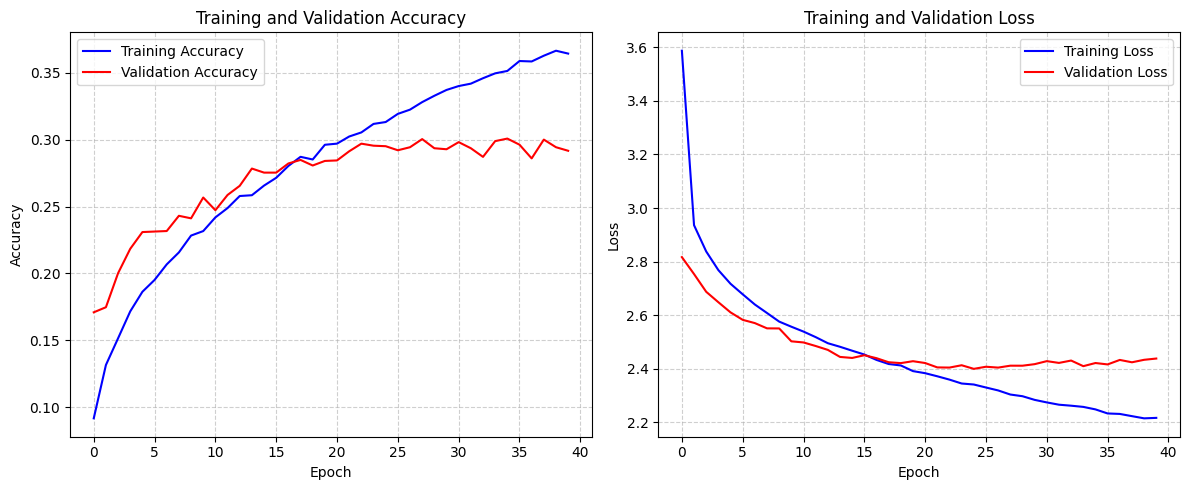


--- Plot Interpretation ---
If Validation Accuracy (Red Line) tracks closely with Training Accuracy (Blue Line), the overfitting is successfully contained.
If Validation Loss continues to rise sharply while Training Loss drops, further measures like increasing Dropout/L2 or image resolution may be needed.


In [ ]:
import matplotlib.pyplot as plt

if 'history' not in locals():
    print("Error: The 'history' object from model.fit() was not found.")
    print("run the training cell (Cell 6) successfully.")
else:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

    print("\n--- Plot Interpretation ---")
    print("If Validation Accuracy (Red Line) tracks closely with Training Accuracy (Blue Line), the overfitting is successfully contained.")
    print("If Validation Loss continues to rise sharply while Training Loss drops, further measures like increasing Dropout/L2 or image resolution may be needed.")

In [ ]:
import tensorflow as tf
import os
import numpy as np
import pandas as pd
import glob
from tqdm import tqdm
from tensorflow.keras import layers, models, Input


TEST_DIR = "/content/data/StyleClassificationIndoors/StyleClassificationIndoors/test"
MODEL_PATH = "final_best_model.keras"
IMG_HEIGHT = 128
IMG_WIDTH = 128
NUM_CLASSES = 17
L2_REG = tf.keras.regularizers.l2(4e-5)

CLASS_NAMES = ['asian', 'boho', 'coastal', 'contemporary', 'craftsman', 'eclectic',
               'farmhouse', 'french-country', 'industrial', 'mediterranean', 'minimalist',
               'modern', 'scandinavian', 'shabby-chic-style', 'southwestern', 'tropical', 'victorian']

MAPPING_PATH = 'external_class_mapping.txt'
PRED_CSV = 'final_submission_tf.csv'



def depthwise_separable_block(x, pointwise_filters, stride=1):
    x = layers.DepthwiseConv2D(kernel_size=3, strides=stride, padding='same', use_bias=False,
                               depthwise_regularizer=L2_REG)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters=pointwise_filters, kernel_size=1, strides=1, padding='same', use_bias=False,
                      kernel_regularizer=L2_REG)(x)
    x = layers.BatchNormalization()(x)
    return x

def se_block(input_feature, ratio=4):
    channel_axis = -1
    filters = input_feature.shape[channel_axis]
    se = layers.GlobalAveragePooling2D()(input_feature)
    se = layers.Dense(filters // ratio, activation='relu', use_bias=True)(se)
    se = layers.Dense(filters, activation='sigmoid', use_bias=True)(se)
    se = layers.Reshape((1, 1, filters))(se)
    return layers.multiply([input_feature, se])

def mobilenet_residual_block(x, filters, stride=1):
    shortcut = x
    x = depthwise_separable_block(x, filters, stride=stride)
    x = layers.Activation('relu')(x)
    x = se_block(x, ratio=4)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False,
                                 kernel_regularizer=L2_REG)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_mobilenet_like(input_shape, num_classes, alpha=1.0):
    inputs = Input(shape=input_shape)
    x = layers.Conv2D(int(32 * alpha), 3, strides=2, padding='same', use_bias=False,
                      kernel_regularizer=L2_REG)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = mobilenet_residual_block(x, int(64 * alpha), stride=1)
    x = mobilenet_residual_block(x, int(128 * alpha), stride=2)
    x = mobilenet_residual_block(x, int(128 * alpha), stride=1)
    x = mobilenet_residual_block(x, int(256 * alpha), stride=2)
    x = mobilenet_residual_block(x, int(256 * alpha), stride=1)
    x = mobilenet_residual_block(x, int(512 * alpha), stride=2)
    for _ in range(5):
        x = mobilenet_residual_block(x, int(512 * alpha), stride=1)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    return models.Model(inputs=inputs, outputs=outputs)

try:

    model = tf.keras.models.load_model(MODEL_PATH)
    print(f" trained model is loaded {MODEL_PATH}")
except Exception as e:
    print(f"Error loading model from {MODEL_PATH}: {e}")
    try:
        model = build_mobilenet_like((IMG_HEIGHT, IMG_WIDTH, 3), NUM_CLASSES, alpha=0.5)
        model.load_weights(MODEL_PATH)
    except Exception as e_rebuild:
        raise SystemExit(f"Model loading failed: {e_rebuild}")

class_to_idx_from_file = {}
use_external_mapping = False

if os.path.exists(MAPPING_PATH):
    try:
        with open(MAPPING_PATH, 'r') as f:
            for line in f:
                if ':' in line:
                    name, idx = line.strip().split(':')
                    class_to_idx_from_file[name.strip()] = int(idx.strip())
        use_external_mapping = True
        print(f"Loaded external mapping from {MAPPING_PATH}.")
    except Exception as e:
        print(f"Error loading mapping file: {e}.")

name_to_dataset_idx = {name: idx for idx, name in enumerate(CLASS_NAMES)}

def load_and_preprocess_image(file_path):

    img = tf.keras.utils.load_img(file_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)


image_extensions = (".jpg", ".jpeg", ".png", ".gif", ".bmp")
all_test_files = sorted([f for f in os.listdir(TEST_DIR) if f.lower().endswith(image_extensions)])
results = []

print(f"\nStarting inference on {len(all_test_files)} images in Test Directory...")

for file_name in tqdm(all_test_files, desc='Predicting'):
    img_path = os.path.join(TEST_DIR, file_name)

    try:
        img_input = load_and_preprocess_image(img_path)

        predictions = model.predict(img_input, verbose=0)
        predicted_index = np.argmax(predictions[0])
        predicted_class_name = CLASS_NAMES[predicted_index]

        if use_external_mapping and predicted_class_name in class_to_idx_from_file:
            numeric_label = class_to_idx_from_file[predicted_class_name]
        else:
            numeric_label = predicted_index

        results.append({
            "ImageName": file_name,
            "ClassLabel": numeric_label
        })

    except Exception as e:
        results.append({
            "ImageName": file_name,
            "ClassLabel": -1
        })
        print(f"\nWarning: Failed to process {file_name} (Corrupted or invalid file). Added as -1.")



pred_df = pd.DataFrame(results)

pred_df.drop_duplicates(subset=['ImageName'], keep='last', inplace=True)
pred_df = pred_df.sort_values('ImageName').reset_index(drop=True)
pred_df.to_csv(PRED_CSV, index=False)

print(f'\n======================================================')
print(f'Saved predictions to {PRED_CSV}. Total rows: {len(pred_df)}')
corrupted_count = pred_df['ClassLabel'].eq(-1).sum()
if corrupted_count > 0:
    print(f"NOTE: {corrupted_count} images were labeled -1 (unprocessed/corrupted).")
print(f'======================================================')

print('Sample predictions:')
print(pred_df.head())

✅ Successfully loaded trained model from final_best_model.keras

Starting inference on 5482 images in Test Directory...


Predicting:  18%|█▊        | 983/5482 [01:33<06:56, 10.80it/s]

Predicting:  48%|████▊     | 2606/5482 [03:46<03:05, 15.49it/s]

Predicting:  49%|████▉     | 2682/5482 [03:52<03:16, 14.26it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Predicting:  49%|████▉     | 2701/5482 [03:53<02:59, 15.46it/s]

Predicting:  65%|██████▍   | 3538/5482 [05:02<02:23, 13.52it/s]

Predicting: 100%|██████████| 5482/5482 [07:40<00:00, 11.90it/s]


Saved predictions to final_submission_tf.csv. Total rows: 5482
NOTE: 4 images were labeled -1 (unprocessed/corrupted).
Sample predictions:
            ImageName  ClassLabel
0     testimage_1.jpg          10
1    testimage_10.jpg          10
2   testimage_100.jpg          10
3  testimage_1000.jpg          16
4  testimage_1001.jpg          10
